In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    accuracy_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt
import seaborn as sns

# Fixed random state
RANDOM_STATE = 36

# Load SBA national data
df = pd.read_csv("SBAnational.csv", header=0, low_memory=False)

print("Current Shape:", df.shape)
print(df.head(3))


Current Shape: (786904, 27)
   LoanNr_ChkDgt                         Name         City State    Zip  \
0     1000014003               ABC HOBBYCRAFT   EVANSVILLE    IN  47711   
1     1000024006  LANDMARK BAR & GRILLE (THE)    NEW PARIS    IN  46526   
2     1000034009        WHITLOCK DDS, TODD M.  BLOOMINGTON    IN  47401   

                      Bank BankState   NAICS ApprovalDate ApprovalFY  ...  \
0         FIFTH THIRD BANK        OH  451120    28-Feb-97       1997  ...   
1          1ST SOURCE BANK        IN  722410    28-Feb-97       1997  ...   
2  GRANT COUNTY STATE BANK        IN  621210    28-Feb-97       1997  ...   

   RevLineCr  LowDoc  ChgOffDate  DisbursementDate  DisbursementGross  \
0          N       Y         NaN         28-Feb-99        $60,000.00    
1          N       Y         NaN         31-May-97        $40,000.00    
2          N       N         NaN         31-Dec-97       $287,000.00    

   BalanceGross  MIS_Status ChgOffPrinGr        GrAppv      SBA_Appv 

In [2]:
# Cleaning Data

# Drop any rows missing fields
df = df.dropna(subset=["Name", "City", "State", "MIS_Status"]).copy()
print("After initial drops:", df.shape)

# Fill missing values for some categorical columns
for col in ["Bank", "BankState", "RevLineCr", "LowDoc"]:
    df[col] = df[col].fillna("O")

# Fix inconsistent ApprovalFY types
# Check inconsistencies
print("ApprovalFY unique BEFORE:", df["ApprovalFY"].unique()[:20])

# Convert to numeric or NaN
df["ApprovalFY"] = pd.to_numeric(
    df["ApprovalFY"]
      .astype(str)
      .str.replace("1976A", "1976", regex=False),
    errors="coerce"
)

# Optional: Confirm any NaN
print("Any NaNs in ApprovalFY after conversion:", df["ApprovalFY"].isna().sum())

# Convert to format that allows NaN
df["ApprovalFY"] = df["ApprovalFY"].astype("Int64")

print("ApprovalFY unique AFTER:", pd.Series(df["ApprovalFY"].unique()).dropna().sort_values().head(10))


After initial drops: (785011, 27)
ApprovalFY unique BEFORE: ['1997' '1980' '2006' '1998' '1999' '2000' '2001' '1972' '2003' '2004'
 '1978' '1979' '1981' '2005' '1982' '1983' '1973' '1984' '2007' '1985']
Any NaNs in ApprovalFY after conversion: 0
ApprovalFY unique AFTER: 41    1968
42    1969
44    1970
46    1971
7     1972
16    1973
28    1974
38    1975
40    1976
39    1977
dtype: Int64


In [3]:
# Standardize Fields

# Normalize LowDoc field to either: Y, N, or U
df["LowDoc"] = df["LowDoc"].astype(str)
df.loc[df["LowDoc"] == "1", "LowDoc"] = "Y"
df.loc[df["LowDoc"] == "0", "LowDoc"] = "N"
df.loc[~df["LowDoc"].isin(["Y", "N"]), "LowDoc"] = "U"

print("LowDoc categories:", df["LowDoc"].value_counts(dropna=False))

# Normalize NewExist to - 1: E (existing) or 2: N (new) or 3: U (unknwon)
df["NewExist"] = df["NewExist"].astype(str)
df.loc[df["NewExist"] == "1.0", "NewExist"] = "E"
df.loc[df["NewExist"] == "2.0", "NewExist"] = "N"
df.loc[~df["NewExist"].isin(["E", "N"]), "NewExist"] = "U"

print("NewExist categories:", df["NewExist"].value_counts(dropna=False))

# RevLineCr will be Y, N. Anything else, U
df["RevLineCr"] = df["RevLineCr"].astype(str)
df.loc[~df["RevLineCr"].isin(["Y", "N"]), "RevLineCr"] = "U"

print("RevLineCr categories:", df["RevLineCr"].value_counts(dropna=False))


LowDoc categories: LowDoc
N    701471
Y     79110
U      4430
Name: count, dtype: int64
NewExist categories: NewExist
E    566171
N    217801
U      1039
Name: count, dtype: int64
RevLineCr categories: RevLineCr
N    361608
U    234613
Y    188790
Name: count, dtype: int64


In [4]:
# Money Columns

money_cols = ["DisbursementGross", "BalanceGross", "ChgOffPrinGr", "GrAppv", "SBA_Appv"]

# remove $, "," and convert to float
for col in money_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
        .astype(float)
    )
# Confirm
df[money_cols].describe()


,DisbursementGross,BalanceGross,ChgOffPrinGr,GrAppv,SBA_Appv
count,7.850110e+05,785011.000000,7.850110e+05,7.850110e+05,7.850110e+05
mean,1.997829e+05,3.288229,1.388848e+04,1.908032e+05,1.473961e+05
std,2.870986e+05,1539.545958,6.539826e+04,2.828326e+05,2.270614e+05
min,4.000000e+03,0.000000,0.000000e+00,1.000000e+03,5.000000e+02
25%,4.083600e+04,0.000000,0.000000e+00,3.500000e+04,2.000000e+04
50%,1.000000e+05,0.000000,0.000000e+00,8.800000e+04,5.780000e+04
75%,2.344880e+05,0.000000,0.000000e+00,2.230000e+05,1.712000e+05
max,1.144632e+07,996262.000000,3.512596e+06,5.472000e+06,5.472000e+06


In [5]:
# Clean US State codes

states = [
    "AL","AK","AZ","AR","CA","CO","CT","DE","FL","GA",
    "HI","ID","IL","IN","IA","KS","KY","LA","ME","MD",
    "MA","MI","MN","MS","MO","MT","NE","NV","NH","NJ",
    "NM","NY","NC","ND","OH","OK","OR","PA","RI","SC",
    "SD","TN","TX","UT","VT","VA","WA","WV","WI","WY"
]

# See which entries are not in states and filter
print("Non-standard State count:", (~df["State"].isin(states)).sum())
print("Non-standard BankState count:", (~df["BankState"].isin(states)).sum())

df = df[(df["State"].isin(states)) & (df["BankState"].isin(states))].copy()
print("Shape after filtering states:", df.shape)


Non-standard State count: 1416
Non-standard BankState count: 4584
Shape after filtering states: (779173, 27)


In [6]:
# Assess SBA Layout
# Seperate Industry

# Create SBA Payout Feature that takes a small portion of SBA_Appv and ChgOffPrinGr to extract pay out guarentee regrdless of default
# This will help distunuish between when loans were paid nothing vs covered at a loss
df["SBA_payout"] = np.minimum(df["SBA_Appv"], df["ChgOffPrinGr"])

# Clean NAICS codes
exact_mapping = {
    11: "Agriculture, forestry, fishing and hunting",
    21: "Mining, quarrying, and oil and gas extraction",
    22: "Utilities",
    23: "Construction",
    42: "Wholesale trade",
    51: "Information",
    52: "Finance and insurance",
    53: "Real estate and rental and leasing",
    54: "Professional, scientific, and technical services",
    55: "Management of companies and enterprises",
    56: "Admin/support/waste mgmt/remediation",
    61: "Educational services",
    62: "Health care and social assistance",
    71: "Arts, entertainment, and recreation",
    72: "Accommodation and food services",
    81: "Other services (except public administration)",
    92: "Public administration",
}

# Specially handing for sectors with multiple rnages
# Convert codes to integer by first 2 digits
def map_naics(code):
    try:
        code2 = int(str(int(code))[:2])
    except:
        return "Unknown"
    if 31 <= code2 <= 33:
        return "Manufacturing"
    elif 44 <= code2 <= 45:
        return "Retail trade"
    elif 48 <= code2 <= 49:
        return "Transportation and warehousing"
    else:
      # Return uknown if missing
        return exact_mapping.get(code2, "Unknown")

# Create new column: industry and produce msot common in the dataset
df["Industry"] = df["NAICS"].apply(map_naics)
print("Industry categories:", df["Industry"].value_counts().head())


Industry categories: Industry
Unknown                                             158661
Retail trade                                        112540
Other services (except public administration)        63992
Professional, scientific, and technical services     61181
Accommodation and food services                      60722
Name: count, dtype: int64


In [7]:
# Drop any unused columns

drop_cols = [
    "LoanNr_ChkDgt",
    "Name",
    "City",
    "ApprovalDate",
    "DisbursementDate",
    "ChgOffDate"
]
# Drop columns and show Structure
df = df.drop(columns=[c for c in drop_cols if c in df.columns])
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 779173 entries, 0 to 786902
Data columns (total 23 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   State              779173 non-null  object 
 1   Zip                779173 non-null  int64  
 2   Bank               779173 non-null  object 
 3   BankState          779173 non-null  object 
 4   NAICS              779173 non-null  int64  
 5   ApprovalFY         779173 non-null  Int64  
 6   Term               779173 non-null  float64
 7   NoEmp              779173 non-null  float64
 8   NewExist           779173 non-null  object 
 9   CreateJob          779173 non-null  float64
 10  RetainedJob        779173 non-null  float64
 11  FranchiseCode      779173 non-null  float64
 12  UrbanRural         779173 non-null  float64
 13  RevLineCr          779173 non-null  object 
 14  LowDoc             779173 non-null  object 
 15  DisbursementGross  779173 non-null  float64
 16  Balance

In [8]:
# Filter for Recession Period

df = df[(df["ApprovalFY"] >= 2007) & (df["ApprovalFY"] <= 2012)].copy()
print("Shape after restricting to 2007–2012:", df.shape)
print("ApprovalFY range:", df["ApprovalFY"].min(), "to", df["ApprovalFY"].max())


Shape after restricting to 2007–2012: (165260, 23)
ApprovalFY range: 2007 to 2012


In [9]:
# Create feature to assess Zip code
# Clean set
def make_zip3(z):

    if pd.isna(z):
        return "000"
    s = str(z).strip()
    # Remove decimals
    if "." in s:
        s = s.split(".")[0]
    # remove anything that is not a digit
    s_digits = "".join(ch for ch in s if ch.isdigit())
    if len(s_digits) == 0:
        return "000"
      # If Zip has < 3, add zeros to fill
    if len(s_digits) < 3:
        s_digits = s_digits.zfill(3)
    if len(s_digits) > 3:
        s_digits = s_digits[:3]
    return s_digits

df["Zip3"] = df["Zip"].apply(make_zip3).astype(str)

print("Sample Zip and Zip3:")
print(df[["Zip", "Zip3"]].head())

# Sanity check
df = df[df["Zip3"] != "000"].copy()
print("Shape after dropping unknown Zip3:", df.shape)


Sample Zip and Zip3:
          Zip Zip3
143841  27103  271
143842   7018  701
143845   7018  701
143846  91743  917
143851   5701  570
Shape after dropping unknown Zip3: (165258, 24)


In [10]:
# Create feature to compare defaults vs fullly paid

# target variables
status_map = {
    "CHGOFF": 1,  # default / charged off
    "P I F": 0,   # paid in full
}

# Keep only rows with one of these two statuses
df_model = df[df["MIS_Status"].isin(status_map.keys())].copy()
df_model["Default"] = df_model["MIS_Status"].map(status_map)

print("Target value counts:\n", df_model["Default"].value_counts())
target_col = "Default"


Target value counts:
 Default
0    110863
1     54395
Name: count, dtype: int64


In [11]:
# Determine average default rates by Zip code

# Calculate mean
zip3_default_rates = df_model.groupby("Zip3")[target_col].mean()

# Add average default feature to loan model
df_model["Average_default_by_Zip"] = df_model["Zip3"].map(zip3_default_rates)

print("Zip3_avg_default stats:")
print(df_model["Average_default_by_Zip"].describe())


Zip3_avg_default stats:
count    165258.000000
mean          0.329152
std           0.125750
min           0.000000
25%           0.233010
50%           0.324619
75%           0.422819
max           1.000000
Name: Average_default_by_Zip, dtype: float64



Default vs Paid-in-Full counts:
Default
0    110863
1     54395
Name: count, dtype: int64


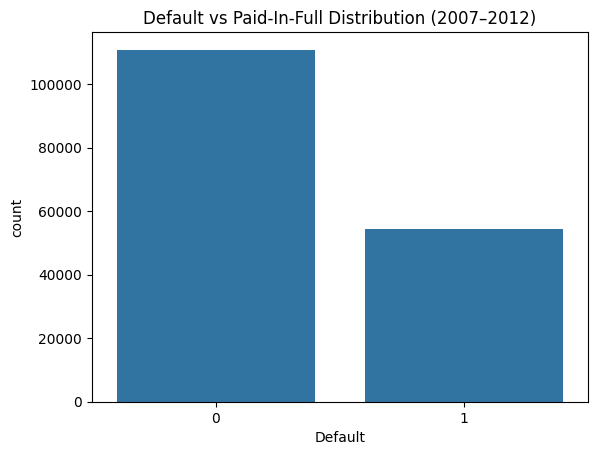

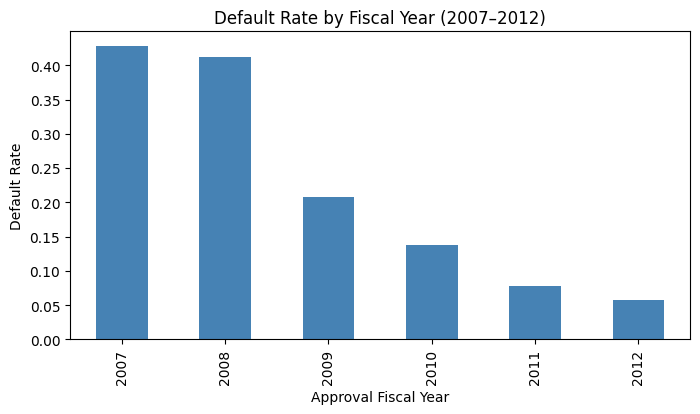


Top 10 highest default-rate states:


,default_rate,n_loans
State,,
FL,0.526165,8370
GA,0.494066,4129
NV,0.491345,1502
CA,0.453739,22308
TN,0.434412,1761
NJ,0.430300,4132
AZ,0.422851,3921
MD,0.409722,2304
SC,0.408811,976



Top 10 lowest default-rate states:


,default_rate,n_loans
State,,
WI,0.187486,4347
KS,0.171711,1619
NE,0.147260,1168
AK,0.145749,247
ME,0.133028,1090
VT,0.127955,719
SD,0.127358,636
MT,0.121888,1165
WY,0.120000,350


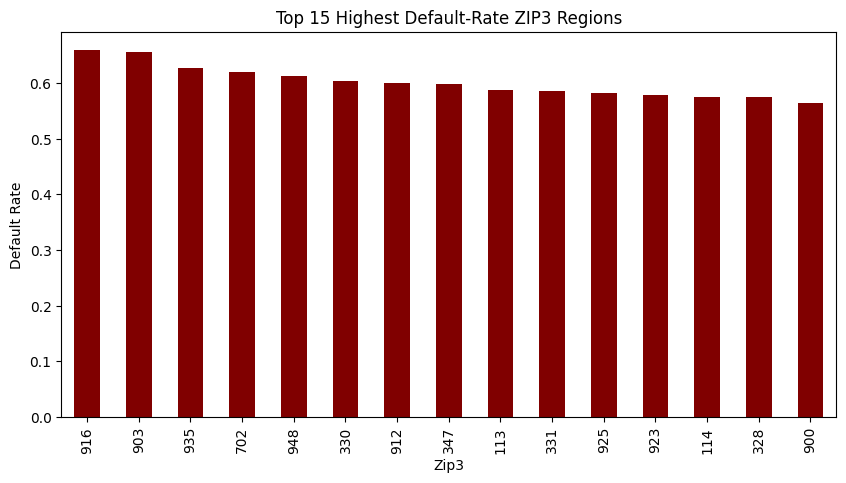

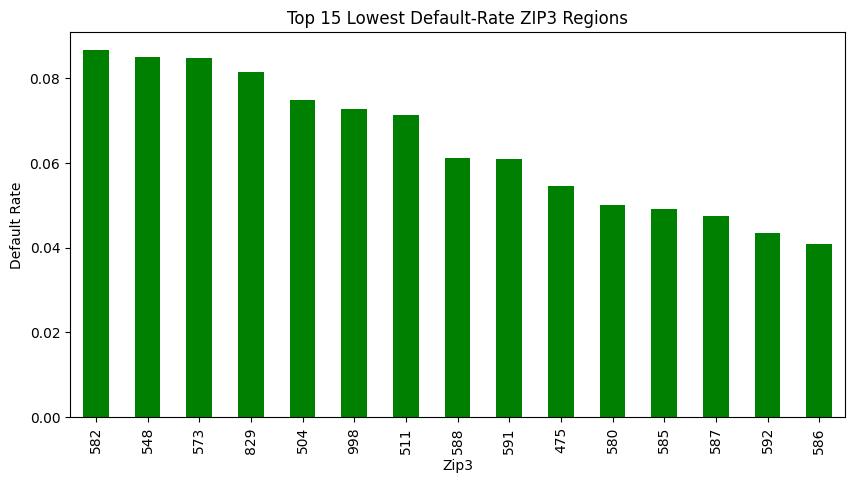

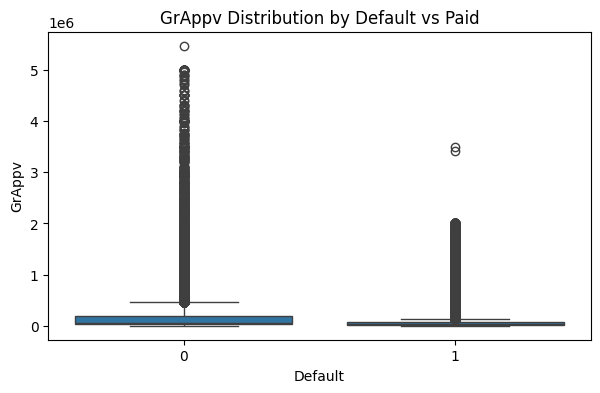

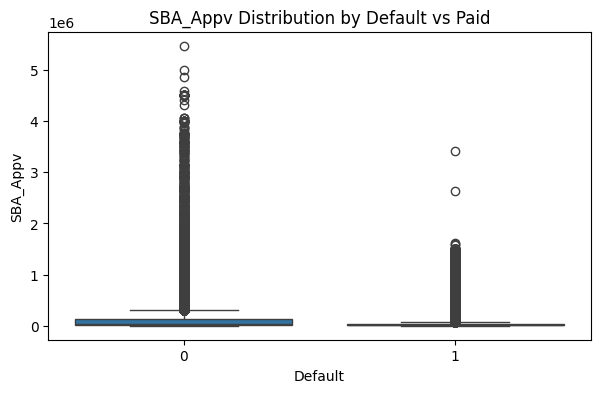

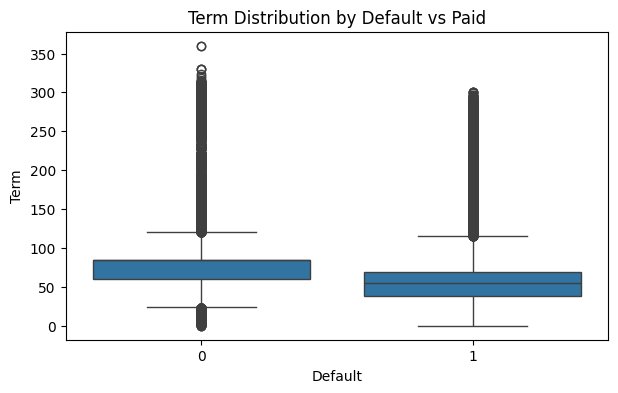

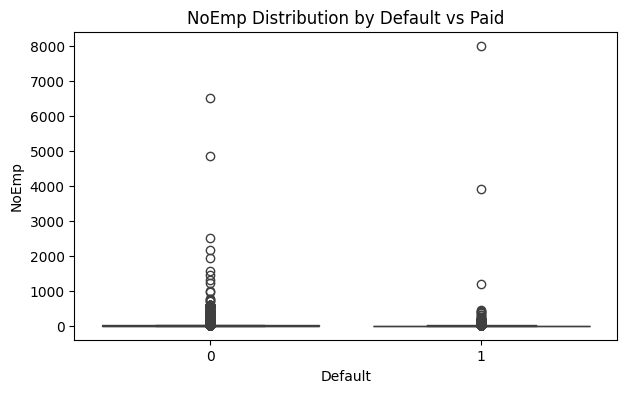


Default Rate by LowDoc:
Default   Paid  Default
LowDoc                 
N        0.672    0.328
U        0.610    0.390

Default Rate by RevLineCr:
Default     Paid  Default
RevLineCr                
N          0.662    0.338
U          0.743    0.257
Y          0.653    0.347

Default Rate by UrbanRural:
Default      Paid  Default
UrbanRural                
0.0         0.739    0.261
1.0         0.646    0.354
2.0         0.777    0.223

Default Rate by NewExist:
Default    Paid  Default
NewExist                
E         0.663    0.337
N         0.686    0.314
U         0.887    0.113

Default Rate by Industry:
Default                                            Paid  Default
Industry                                                        
Accommodation and food services                   0.677    0.323
Admin/support/waste mgmt/remediation              0.644    0.356
Agriculture, forestry, fishing and hunting        0.888    0.112
Arts, entertainment, and recreation               0.6

In [23]:
# Exploraroty Data Analysis

# Default distribution

print("\nDefault vs Paid-in-Full counts:")
print(df_model["Default"].value_counts())

sns.countplot(data=df_model, x="Default")
plt.title("Default vs Paid-In-Full Distribution (2007–2012)")
plt.show()

# Default Rate by Year (2007–2012)

yr_default = df_model.groupby("ApprovalFY")["Default"].mean()

plt.figure(figsize=(8,4))
yr_default.plot(kind="bar", color="steelblue")
plt.title("Default Rate by Fiscal Year (2007–2012)")
plt.ylabel("Default Rate")
plt.xlabel("Approval Fiscal Year")
plt.show()

# Default Rate by State

state_default = (
    df_model.groupby("State")["Default"]
    .agg(["mean", "count"])
    .rename(columns={"mean":"default_rate", "count":"n_loans"})
    .sort_values("default_rate", ascending=False)
)

print("\nTop 10 highest default-rate states:")
display(state_default.head(10))

print("\nTop 10 lowest default-rate states:")
display(state_default.tail(10))

# Default Rate by ZIP3 (only ZIP3s with >= 40 loans)

zip3_counts = df_model["Zip3"].value_counts()
valid_zip3s = zip3_counts[zip3_counts >= 40].index

zip3_default = (
    df_model[df_model["Zip3"].isin(valid_zip3s)]
    .groupby("Zip3")["Default"].mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))
zip3_default.head(15).plot(kind="bar", color="maroon")
plt.title("Top 15 Highest Default-Rate ZIP3 Regions")
plt.ylabel("Default Rate")
plt.show()

plt.figure(figsize=(10,5))
zip3_default.tail(15).plot(kind="bar", color="green")
plt.title("Top 15 Lowest Default-Rate ZIP3 Regions")
plt.ylabel("Default Rate")
plt.show()

# Numeric feature comparison (Default vs Paid)

num_cols_to_check = ["GrAppv", "SBA_Appv", "Term", "NoEmp"]

for col in num_cols_to_check:
    plt.figure(figsize=(7,4))
    sns.boxplot(data=df_model, x="Default", y=col)
    plt.title(f"{col} Distribution by Default vs Paid")
    plt.show()

# Categorical comparison tables

for col in ["LowDoc", "RevLineCr", "UrbanRural", "NewExist", "Industry"]:
    print(f"\nDefault Rate by {col}:")
    print(
        pd.crosstab(df_model[col], df_model["Default"], normalize="index")
        .rename(columns={0:"Paid", 1:"Default"})
        .round(3)
    )


In [13]:
# Build Model

# Drop uneeded columns including original zip
cols_to_drop_for_X = [
    target_col,
    "MIS_Status",
    "Zip",
    "ChgOffPrinGr",
    "SBA_payout",
]
# Build feature matrix + target
X = df_model.drop(columns=[c for c in cols_to_drop_for_X if c in df_model.columns])
y = df_model[target_col]

print("Final feature columns:", X.columns.tolist())
print("X shape:", X.shape, "| y shape:", y.shape)


Final feature columns: ['State', 'Bank', 'BankState', 'NAICS', 'ApprovalFY', 'Term', 'NoEmp', 'NewExist', 'CreateJob', 'RetainedJob', 'FranchiseCode', 'UrbanRural', 'RevLineCr', 'LowDoc', 'DisbursementGross', 'BalanceGross', 'GrAppv', 'SBA_Appv', 'Industry', 'Zip3', 'Average_default_by_Zip']
X shape: (165258, 21) | y shape: (165258,)


In [14]:
# Create Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)


Train shape: (132206, 21) | Test shape: (33052, 21)


In [15]:
# Preproccessing

# Seperate Categorical Features from Numeric Features
categorical_cols = [
    col for col in ["State", "BankState", "LowDoc", "RevLineCr",
                    "NewExist", "Industry", "Zip3"]
    if col in X_train.columns
]

numeric_cols = [
    col for col in [
        "Term", "NoEmp", "CreateJob", "RetainedJob",
        "GrAppv", "SBA_Appv", "DisbursementGross",
        "BalanceGross", "ApprovalFY", "NAICS",
        "Zip3_avg_default"
    ]
    if col in X_train.columns
]

print("Categorical cols:", categorical_cols)
print("Numeric cols:", numeric_cols)


Categorical cols: ['State', 'BankState', 'LowDoc', 'RevLineCr', 'NewExist', 'Industry', 'Zip3']
Numeric cols: ['Term', 'NoEmp', 'CreateJob', 'RetainedJob', 'GrAppv', 'SBA_Appv', 'DisbursementGross', 'BalanceGross', 'ApprovalFY', 'NAICS']


In [16]:
# Preproccessing:
# Numeric Data - StandardizedScalar
# categorical - OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ],
    remainder="drop"
)

# Logistic Regression
log_reg_clf = LogisticRegression(
    max_iter=500,
    solver="saga",
    class_weight="balanced",
    n_jobs=-1,
    random_state=RANDOM_STATE
)

model = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("clf", log_reg_clf),
    ]
)

print("Fitting logistic regression model...")
model.fit(X_train, y_train)

Fitting logistic regression model...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Term', 'NoEmp', 'CreateJob',
                                                   'RetainedJob', 'GrAppv',
                                                   'SBA_Appv',
                                                   'DisbursementGross',
                                                   'BalanceGross', 'ApprovalFY',
                                                   'NAICS']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['State', 'BankState',
                                                   'LowDoc', 'RevLineCr',
                                                   'NewExist', 'Industry',
                                                   'Zip3'])])),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=500,
                                    n_jobs=-1, random_state=36,
                                    solver='saga'))])

In [17]:
# Training

train_pred = model.predict(X_train)
train_acc = accuracy_score(y_train, train_pred)
print(f"Training Accuracy: {train_acc:.3f}")

Training Accuracy: 0.784


Test ROC-AUC: 0.859

Classification report:
              precision    recall  f1-score   support

           0       0.90      0.77      0.83     22173
           1       0.63      0.82      0.71     10879

    accuracy                           0.78     33052
   macro avg       0.76      0.79      0.77     33052
weighted avg       0.81      0.78      0.79     33052



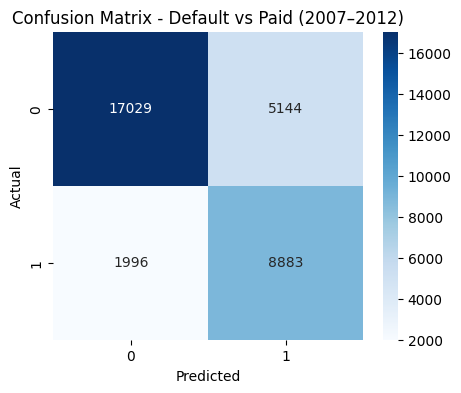

In [18]:
# Evaluate

# Predicted probabilities for ROC-AUC
y_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)


auc = roc_auc_score(y_test, y_proba)
print(f"Test ROC-AUC: {auc:.3f}")

# Dsiplay results
print("\nClassification report:")
print(classification_report(y_test, y_pred))


cm = confusion_matrix(y_test, y_pred)
# Heatmap for visual
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Default vs Paid (2007–2012)")
plt.show()


In [21]:
# Summary

zip3_summary = (
    df_model.groupby("Zip3")["Default"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "default_rate", "count": "n_loans"})
    # sort Zip regions from highest risk
    .sort_values("default_rate", ascending=False)
)

print(zip3_summary.head(10))   # top 10 highest default-rate ZIP3 regions
print(zip3_summary.tail(10))   # bottom 10 (safest) ZIP3 regions


      default_rate  n_loans
Zip3                       
909       1.000000        1
849       1.000000        1
878       1.000000        1
369       1.000000        1
842       1.000000        1
332       1.000000        4
536       0.750000        4
916       0.658879      214
903       0.656250       96
367       0.636364       11
      default_rate  n_loans
Zip3                       
414            0.0        2
416            0.0        6
004            0.0        1
725            0.0       17
901            0.0        1
499            0.0       13
695            0.0        1
516            0.0        4
669            0.0        4
008            0.0        1


Summary

The final model shows strong predictive performance and economic insight into SBA loan outcomes during the 2007–2012 recession. It achieves a ROC-AUC of 0.859 on the test set—indicating excellent ability to rank high-risk borrowers—and its training accuracy is closely aligned with the test accuracy (0.78). The model also correctly captured 82% of all defaults while maintaining 90% precision for fully repaid loans